Figure out why there's such a large degeneracy between sigma & dsigma/dM

In [1]:
from escripts import eMCMC
from escripts import eplots
from escripts import edata
import importlib

In [2]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [3]:
params = eMCMC.build_param_data({'dsigdz':{'fit':False, 'value': 0}})

In [34]:
Mhpivot = 11
my_UVLF = eMCMC.UVLF(sorted_data, params, Mhpivot = Mhpivot)

In [35]:
my_UVLF.run_MCMC()

  0%|                                                                                                                                                    | 0/100000 [00:00<?, ?it/s]/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [1:59:26<00:00, 13.95it/s]


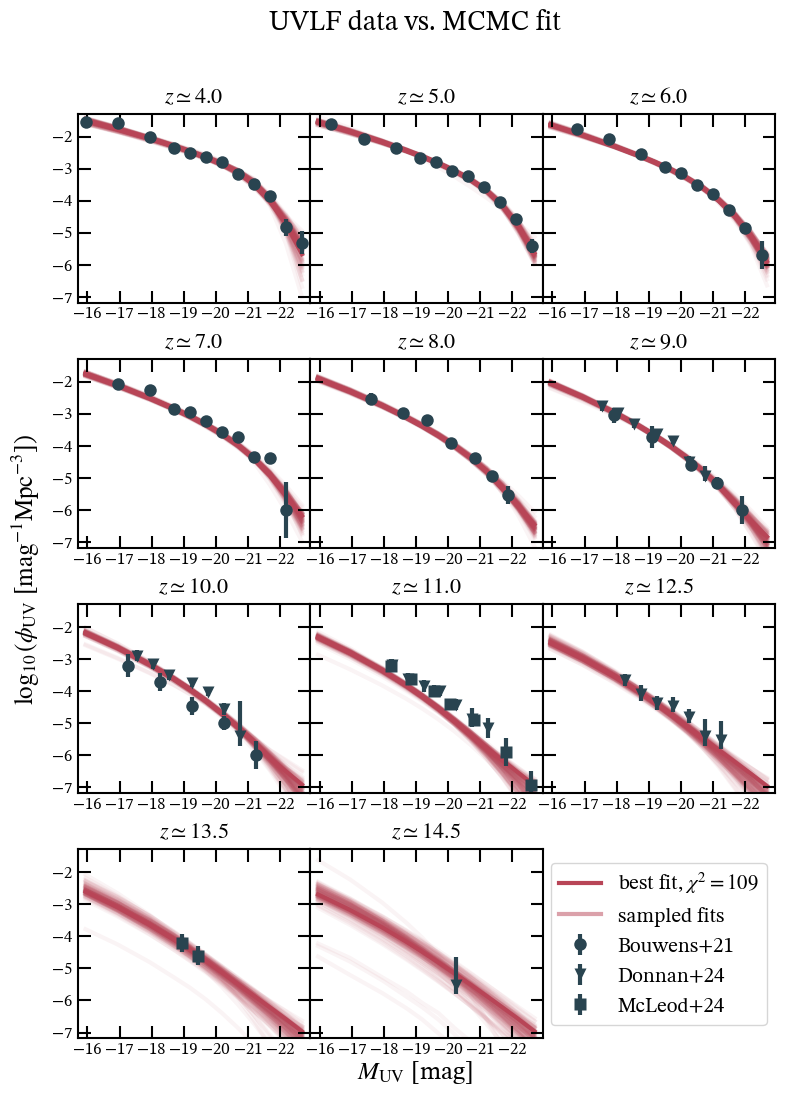

In [36]:
fit = eplots.evolving_UVLF_fit(my_UVLF)

In [37]:
sig_samples, best_fit, _, labels = my_UVLF.get_fit(exclude_unfit = False,
    excluded_params = ['alpha', 'dalphadz', 'beta', 'dbetadz', 'logMc', 'dlogMcdz', 'loge', 'dlogedz', 'dsigdz'])

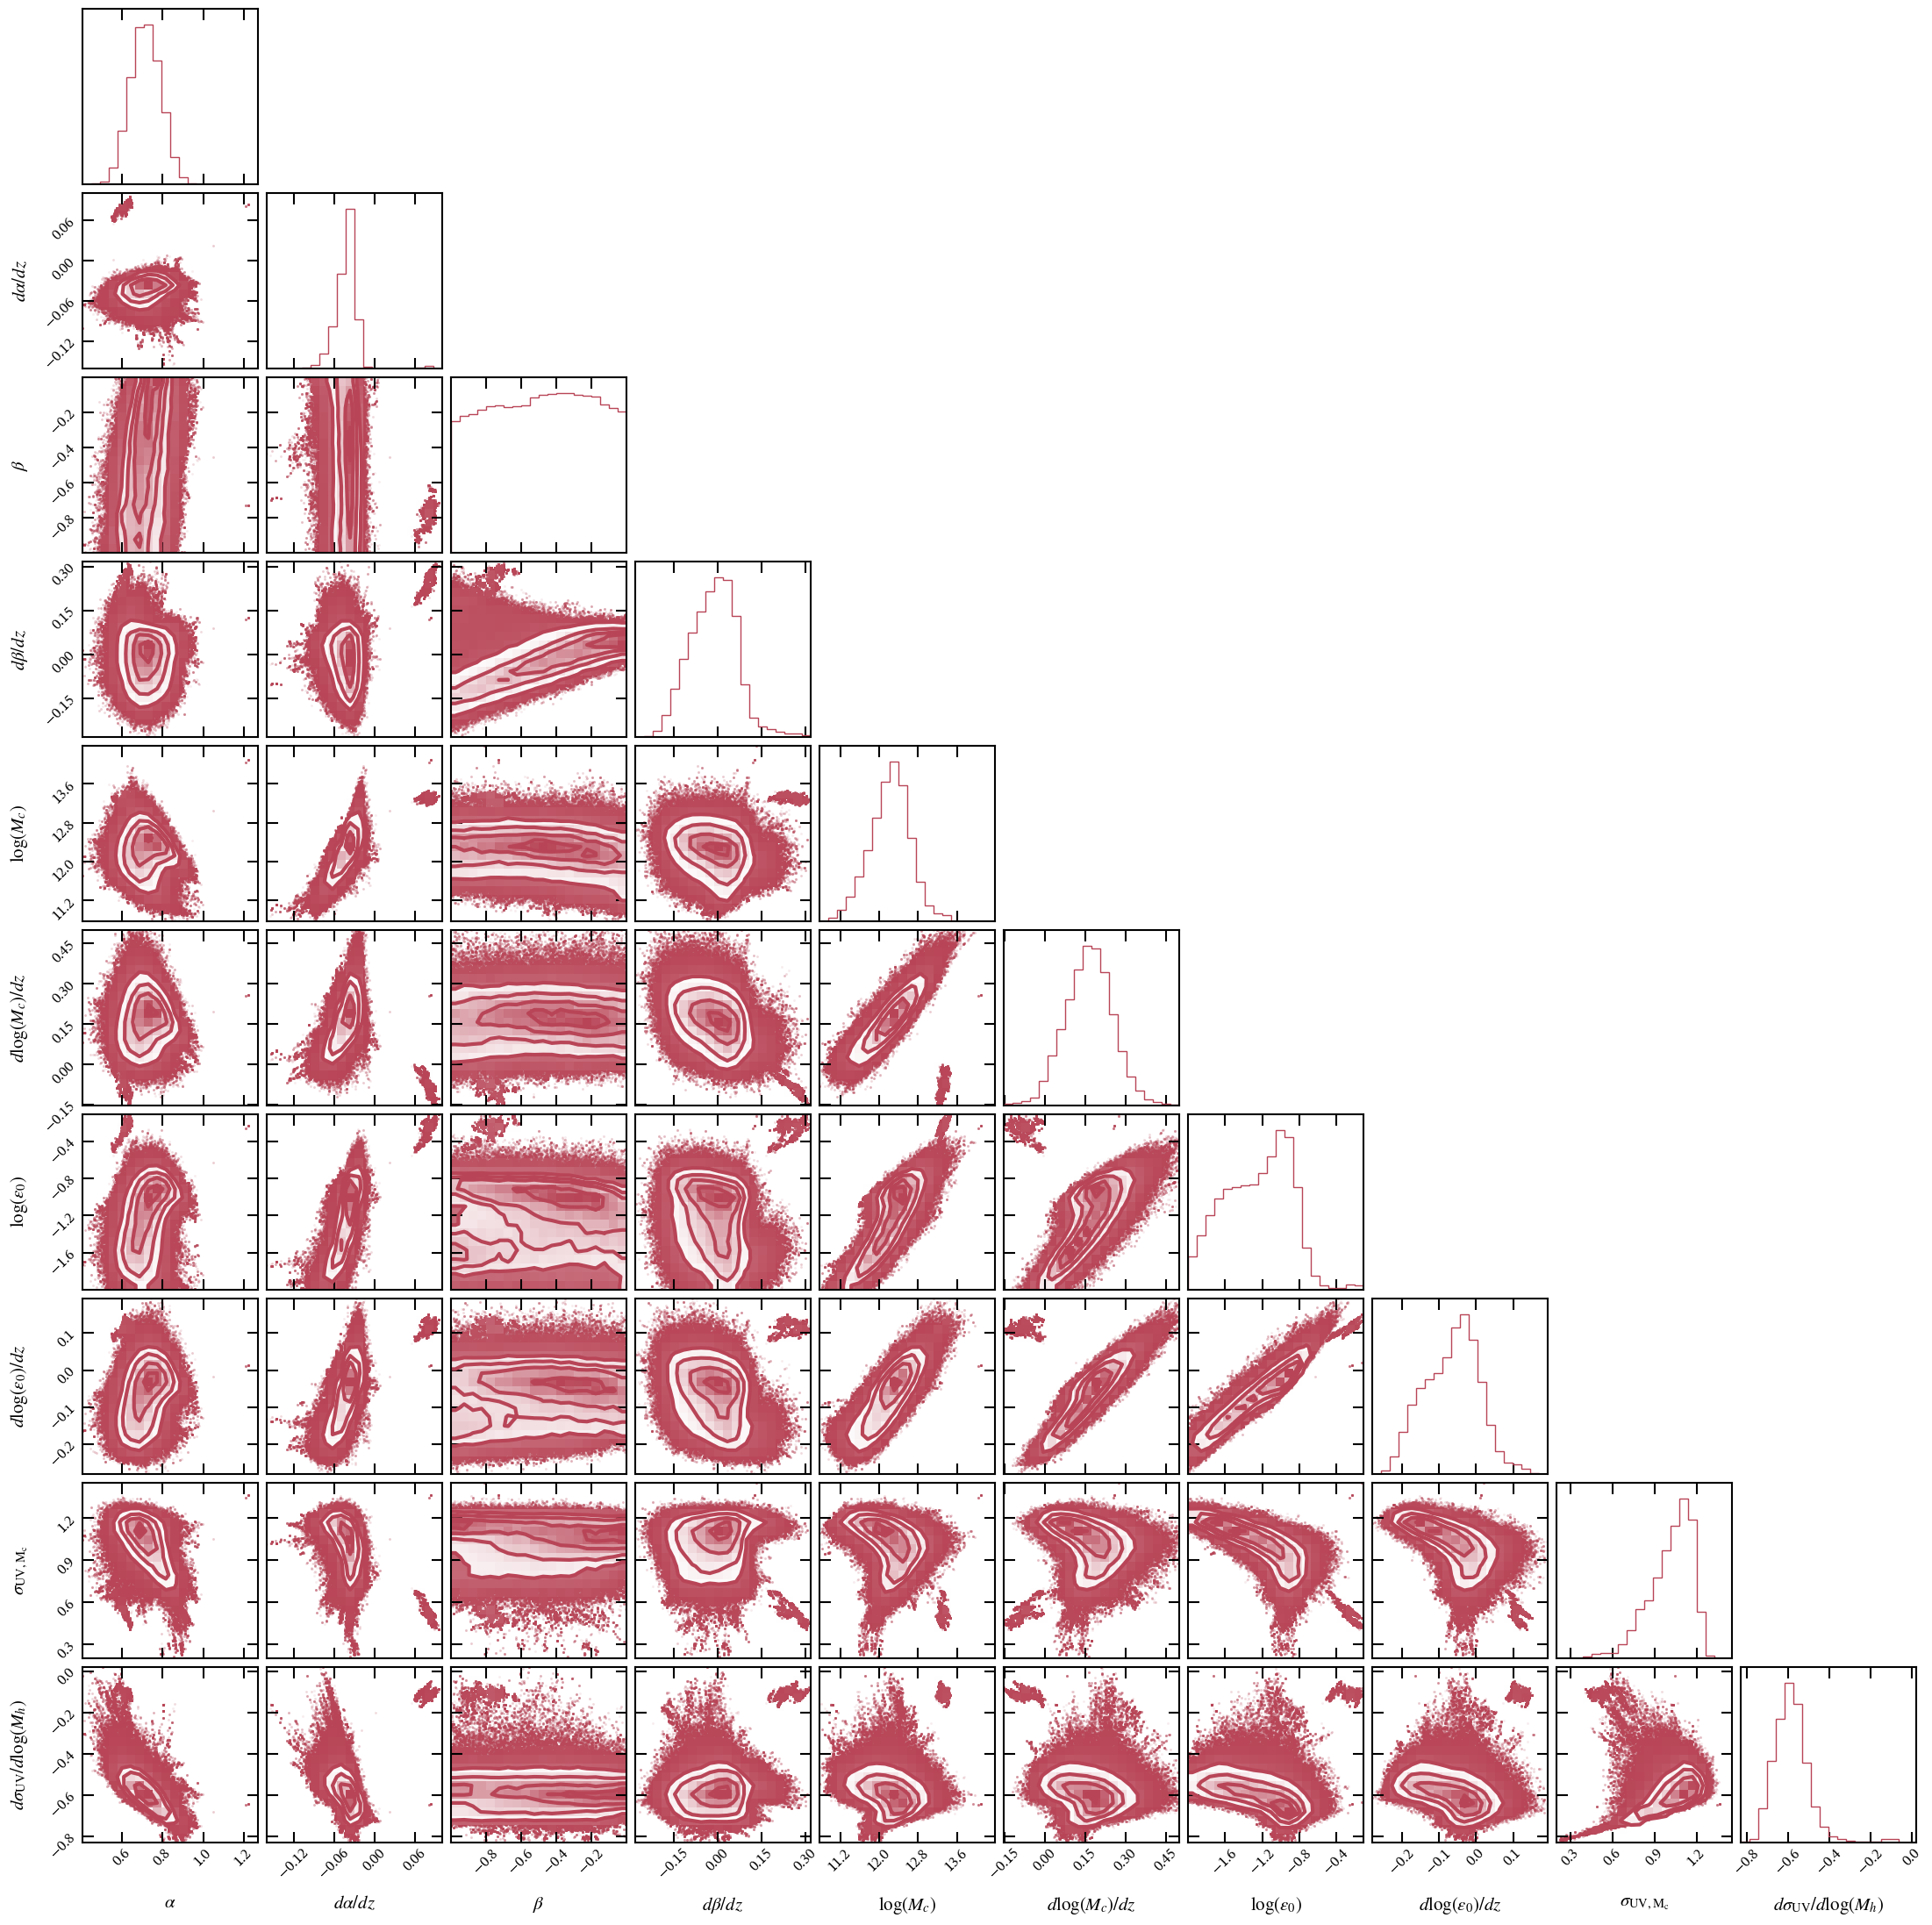

In [38]:
corner = eplots.make_corner(my_UVLF)

In [39]:
#corner.savefig('/Users/eb35267/Desktop/code/figures/sigma_degeneracy/corner_pivot12.png', bbox_inches = 'tight')

Text(0.5, 1.0, '500 samples from MCMC chain, no $z$ dependence')

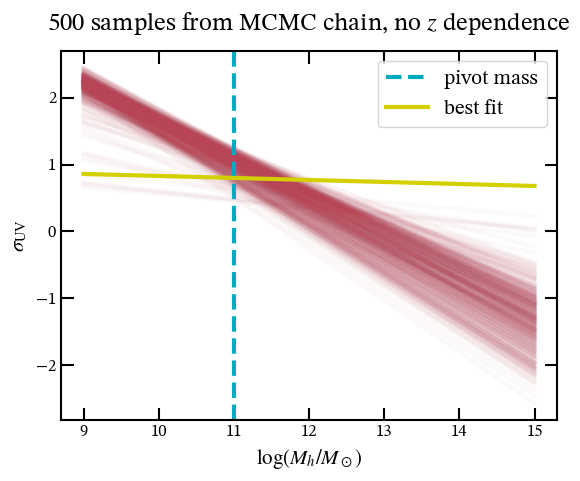

In [42]:
fig, ax = plt.subplots()
N = 500
Ms = np.linspace(9, 15, 3)
mass_pivot = 11

np.random.shuffle(sig_samples) # Randomize the order of samples so you're not just taking the first 500

for sig0, dsigdM in zip(sig_samples[:N,0], sig_samples[:N,1]):
    ax.plot(Ms, (sig0 + dsigdM*(Ms-mass_pivot)), color = eplots.red, linestyle = '-', alpha = 15/N)

plt.axvline(mass_pivot, color = eplots.turquoise, ls = '--', label = 'pivot mass')
ax.plot(Ms, (best_fit[0] + best_fit[1]*(Ms-mass_pivot)), color = eplots.yellow, label = 'best fit')
ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel(r'$\log(M_h/M_\odot)$')
ax.legend()
plt.title(f'{N} samples from MCMC chain, no $z$ dependence')

In [43]:
fig.savefig('/Users/eb35267/Desktop/code/figures/Mhpivot.png', bbox_inches='tight')